In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob, os
import matplotlib.path as mpath

/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_2404/3789507531.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
home_dir = "/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/"
manuscript_dir = home_dir + "Work/Manuscripts/2019_06 SO CMIP Comparison/"



In [157]:
variable_list = {}

variable_list['MLD'] = {'var_name': 'mlotst', 'clim': [0,250], 'units': 'MLD', 'color_map': 'spring'}
variable_list['SST'] = {'var_name': 'tos', 'clim': [0,22], 'units': 'C', 'color_map': 'cool'}
variable_list['SSS'] = {'var_name': 'sos', 'clim': [32,34], 'units': 'psu', 'color_map': 'Wistia'}
variable_list['NPP'] = {'var_name': 'intpp', 'clim': [0, 700], 'units': 'mg C m-2 d-1', 'color_map': 'autumn'}
variable_list['CO2 flux'] = {'var_name': 'fgco2', 'clim': [-5, 5], 'units': 'mol C m-2 yr-1', 'color_map': 'RdBu_r'}
variable_list['pCO2'] = {'var_name': 'spco2', 'clim': [375, 410], 'units': 'uatm', 'color_map': 'plasma'}
variable_list['DIC'] = {'var_name': 'dissic', 'clim': [2000, 2300], 'units': 'umol kg-1', 'color_map': 'copper_r'}
variable_list['TA'] = {'var_name': 'talk', 'clim': [2200, 2450], 'units': 'umol kg-1', 'color_map': 'winter'}

variable_list.keys()

for var_n in variable_list.keys():
    print(var_n)
    var_name = variable_list[var_n]['var_name']
    c_lim = variable_list[var_n]['clim']
    units = variable_list[var_n]['units']
    color_map = variable_list[var_n]['color_map']
    # print(var_name)
        
    var_dir = manuscript_dir + 'data/surface_fields/' + var_name + '/'

    file_list = []
    for file in os.listdir(var_dir):
        if file.endswith('.mat'):
            file_list.append(file)

    print(len(file_list))
    plot_count = 0
    proj = ccrs.SouthPolarStereo()
    data_proj = ccrs.PlateCarree()

    plot_lon_limit = [-180, 180]
    plot_lat_limit = [-90, -35]

    # Compute a circle in axes coordinates, which we can use as a boundary
    # for the map. We can pan/zoom as much as we like - the boundary will be
    # permanently circular.
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)

    num_rows  =5
    num_cols = 4
    fig = plt.figure(figsize=(15, 17), )

    # var_name='MLD'
    page_num = 1
    
    plot_filename = 'Figure SX_' + var_n

    for file in sorted(file_list)[1:]:

        plot_count = plot_count+1

        if plot_count==1: # plot obs in first position of each page
            data = sio.loadmat(var_dir + sorted(file_list)[0])

            ax = plt.subplot(num_rows, num_cols, plot_count, projection=proj)
            ax.gridlines()
            # ax.add_feature(cfeature.LAND, linestyle='-', edgecolor='grey', zorder=10)
            ax.set_extent([-180, 180,  plot_lat_limit[0], plot_lat_limit[1]], ccrs.PlateCarree())
            ax.coastlines(resolution='110m')
            ax.set_boundary(circle, transform=ax.transAxes)
            mesh = ax.pcolormesh(
                data['lon_grid'],
                data['lat_grid'],
                data['SO_var'],
                transform=data_proj, cmap=color_map, clim=c_lim, linewidth=0,rasterized=True)
            if len(data['model_SAF'])>1:
                ax.plot(data['model_SAF'][1,:],data['model_SAF'][0,:], color='m', transform=data_proj, linewidth=2)
            ax.plot(np.linspace(0,360,360),np.linspace(-65,-65,360), color='m', transform=data_proj, linewidth=2)
            ax.set_title(data['model_name'].item())
            plt.colorbar(mesh, label=var_n + ' (' + units + ')')

            plot_count = plot_count+1

        data = sio.loadmat(var_dir + file)

        ax = plt.subplot(num_rows, num_cols, plot_count, projection=proj)
        ax.gridlines()
        # ax.add_feature(cfeature.LAND, linestyle='-', edgecolor='grey', zorder=10)
        ax.set_extent([-180, 180,  plot_lat_limit[0], plot_lat_limit[1]], ccrs.PlateCarree())
        ax.coastlines(resolution='110m')
        ax.set_boundary(circle, transform=ax.transAxes)
        mesh = ax.pcolormesh(
            data['lon_grid'],
            data['lat_grid'],
            data['SO_var'],
            transform=data_proj, cmap=color_map, clim=c_lim,linewidth=0, rasterized=True)
        if len(data['model_SAF'])>1:
            ax.plot(data['model_SAF'][1,:],data['model_SAF'][0,:], color='m', transform=data_proj, linewidth=2)
        ax.plot(np.linspace(0,360,360),np.linspace(-65,-65,360), color='m', transform=data_proj, linewidth=2)
        ax.set_title(data['model_name'].item())

        # plt.show()

        # if plot_count==2:
        #     break
        if plot_count==num_rows*num_cols:
            # break
            # plt.show()
            plt.tight_layout()

            plt.savefig(f'{manuscript_dir + 'figures/'}{plot_filename + '_' + str(page_num)}.pdf', dpi=300)
            plt.clf()
            plot_count=0
            page_num = page_num+1

    plt.tight_layout()
    # save final figure even if you didn't reach an even number 
    plt.savefig(f'{manuscript_dir + 'figures/'}{plot_filename + '_' + str(page_num)}.pdf', dpi=300)

    plt.clf()


MLD
30
SST
45
SSS
44
NPP
41
CO2 flux
46
pCO2
39
DIC
39
TA
36


<Figure size 1500x1700 with 0 Axes>

<Figure size 1500x1700 with 0 Axes>

<Figure size 1500x1700 with 0 Axes>

<Figure size 1500x1700 with 0 Axes>

<Figure size 1500x1700 with 0 Axes>

<Figure size 1500x1700 with 0 Axes>

<Figure size 1500x1700 with 0 Axes>

<Figure size 1500x1700 with 0 Axes>

#### Monthly Hovmoeller of flux

In [155]:
variable_list = {}

variable_list['CO2 flux'] = {'var_name': 'fgco2', 'clim': [-5, 5], 'units': 'Tg C mon-1 lat-1', 'color_map': 'RdYlBu_r'}
variable_list.keys()
for var_n in variable_list.keys():

    print(var_n)
    var_name = variable_list[var_n]['var_name']
    c_lim = variable_list[var_n]['clim']
    units = variable_list[var_n]['units']
    color_map = variable_list[var_n]['color_map']
    # print(var_name)
        
    var_dir = manuscript_dir + 'data/surface_fields/' + var_name + '/'

    file_list = []
    for file in os.listdir(var_dir):
        if file.endswith('.mat'):
            file_list.append(file)

    print(len(file_list))
    plot_count = 0
    plot_lat_limit = [-90, -35]

    num_rows  =5
    num_cols = 4
    fig = plt.figure(figsize=(15, 17), )

    # var_name='MLD'
    page_num = 1
    
    plot_filename = 'Figure SY_' + var_n + '_Monthly_Hovmoeller'

    for file in sorted(file_list)[1:]:

        plot_count = plot_count+1

        if plot_count==1: # plot obs in first position of each page
            data = sio.loadmat(var_dir + sorted(file_list)[0])

            ax = plt.subplot(num_rows, num_cols, plot_count)
            mesh = ax.pcolormesh(
                        data['mon_lab'],
                        data['lat_lab'],
                        data['SO_flux_Tg_mon'], cmap=color_map, clim=c_lim,linewidth=0, rasterized=True)
            plt.colorbar(mesh, label=var_n + ' (' + units + ')')
            plt.hlines(xmin=0, xmax=13, y=-65, color='m')
            ax.set_title(data['model_name'].item())
            ax.xaxis.set_ticks(range(1,13))
            ax.set_ylim([-75, -35])
            ax.set_xlim([0.5, 12.5])

            ax.set_ylabel('Latitude')
            ax.set_xlabel('Month')
            plot_count = plot_count+1

        data = sio.loadmat(var_dir + file)
        # data['SO_flux_Tg_mon'].shape


        ax = plt.subplot(num_rows, num_cols, plot_count)
        mesh = ax.pcolormesh(
                        data['mon_lab'],
                        data['lat_lab'],
                        data['SO_flux_Tg_mon'], cmap=color_map, clim=c_lim,linewidth=0, rasterized=True)
        plt.hlines(xmin=0, xmax=13, y=-65, color='m')

        ax.set_title(data['model_name'].item())
        ax.xaxis.set_ticks(range(1,13))
        ax.set_ylim([-75, -35])
        ax.set_xlim([0.5, 12.5])    

        # break
        if plot_count==num_rows*num_cols:
            # break
            # plt.show()
            plt.tight_layout()

            plt.savefig(f'{manuscript_dir + 'figures/'}{plot_filename + '_' + str(page_num)}.pdf', dpi=300)
            plt.clf()
            plot_count=0
            page_num = page_num+1
    plt.tight_layout()
    # save final figure even if you didn't reach an even number 
    plt.savefig(f'{manuscript_dir + 'figures/'}{plot_filename + '_' + str(page_num)}.pdf', dpi=300)

    plt.clf()

CO2 flux
46


<Figure size 1500x1700 with 0 Axes>

(45, 12)

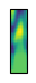

TypeError: unhashable type: 'numpy.ndarray'